<a href="https://colab.research.google.com/github/alxmzr/Colab/blob/main/RSI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_5267/3401078154.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, period='60d', interval=interval)
[*********************100%***********************]  1 of 1 completed
Optimizing 15m: 100%|██████████| 14/14 [00:03<00:00,  3.98it/s]
/tmp/ipykernel_5267/3401078154.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, period='60d', interval=interval)
[*********************100%***********************]  1 of 1 completed


Optimizing 1h: 100%|██████████| 14/14 [00:01<00:00,  9.49it/s]


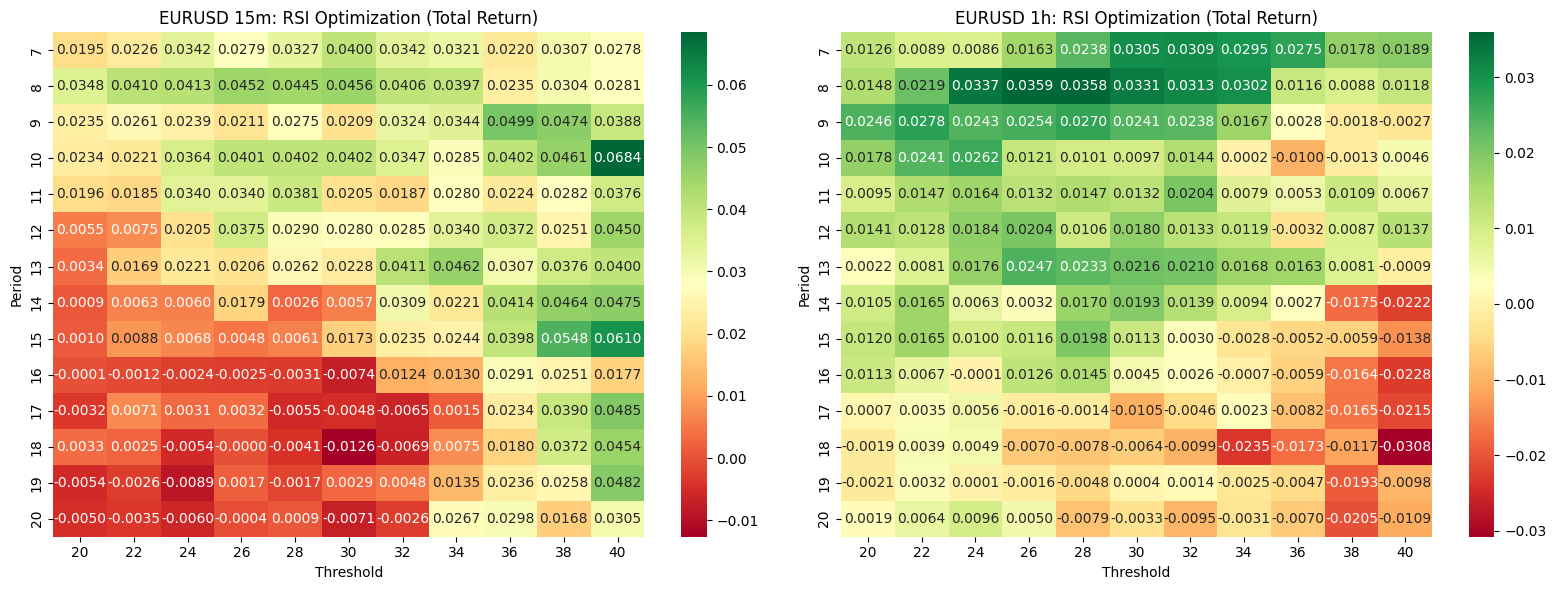

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def backtest_rsi(df, period, overbought, oversold):
    df = df.copy()
    df['RSI'] = calculate_rsi(df['Close'], window=period)
    df['Signal'] = 0
    df.loc[df['RSI'] < oversold, 'Signal'] = 1  # Buy
    df.loc[df['RSI'] > overbought, 'Signal'] = -1  # Sell

    df['Return'] = df['Close'].pct_change()
    df['Strategy_Return'] = df['Signal'].shift(1) * df['Return']
    return df['Strategy_Return'].sum()

def run_optimization(symbol, interval, period_range, threshold_range):
    print(f"Downloading data for {symbol} ({interval})...")
    data = yf.download(symbol, period='60d', interval=interval)

    results = []
    for p in tqdm(period_range, desc=f"Optimizing {interval}"):
        for t in threshold_range:
            overbought = 100 - t
            oversold = t
            ret = backtest_rsi(data, p, overbought, oversold)
            results.append({'Period': p, 'Threshold': t, 'Return': ret})

    return pd.DataFrame(results)

# Parameters for research
symbol = 'EURUSD=X'
periods = range(7, 21)
thresholds = range(20, 41, 2) # e.g., 30 means (30/70), 20 means (20/80)

# Run for 15m and 1h
res_15m = run_optimization(symbol, '15m', periods, thresholds)
res_1h = run_optimization(symbol, '1h', periods, thresholds)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

pivot_15m = res_15m.pivot(index='Period', columns='Threshold', values='Return')
sns.heatmap(pivot_15m, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax1)
ax1.set_title('EURUSD 15m: RSI Optimization (Total Return)')

pivot_1h = res_1h.pivot(index='Period', columns='Threshold', values='Return')
sns.heatmap(pivot_1h, annot=True, fmt='.4f', cmap='RdYlGn', ax=ax2)
ax2.set_title('EURUSD 1h: RSI Optimization (Total Return)')

plt.tight_layout()
plt.show()

In [ ]:
best_15m = res_15m.loc[res_15m['Return'].idxmax()]
best_1h = res_1h.loc[res_1h['Return'].idxmax()]

print("Найкращі параметри для 15м:")
print(f"Період: {int(best_15m['Period'])}, Поріг (Oversold/Overbought): {int(best_15m['Threshold'])} / {100 - int(best_15m['Threshold'])}")
print(f"Прибутковість: {best_15m['Return']:.6f}")

print("\nНайкращі параметри для 1г:")
print(f"Період: {int(best_1h['Period'])}, Поріг (Oversold/Overbought): {int(best_1h['Threshold'])} / {100 - int(best_1h['Threshold'])}")
print(f"Прибутковість: {best_1h['Return']:.6f}")

Найкращі параметри для 15м:
Період: 10, Поріг (Oversold/Overbought): 40 / 60
Прибутковість: 0.068443

Найкращі параметри для 1г:
Період: 8, Поріг (Oversold/Overbought): 26 / 74
Прибутковість: 0.035910
